## Task 2: Hate Speech Detection

### 1.	Data Exploration and Pre-processing

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load the hate speech dataset
df = pd.read_csv("labeled_data.csv")

# Display the first five records
df.head(8)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...


### 1.2 Dataset Overview and Structure

In [6]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names and data types
df.info()



Dataset Shape: (24783, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [7]:
# Display summary statistics for numerical columns
df.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


### 1.3 Check for Missing Values

In [9]:
# Check for missing values in each column
df.isnull().sum()


Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

### 1.4 Target Variable Analysis (Class Distribution)

In [11]:
# Display class distribution
df['class'].value_counts()


class
1    19190
2     4163
0     1430
Name: count, dtype: int64

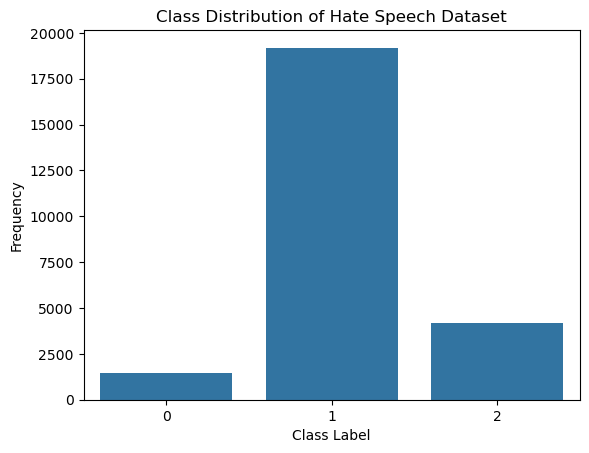

In [12]:
# Visualise class imbalance
plt.figure()
sns.countplot(x='class', data=df)
plt.title("Class Distribution of Hate Speech Dataset")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.show()


### 1.5 Text Data Inspection

In [14]:
# Inspect sample tweets
df['tweet'].sample(5, random_state=42)


2281           934 8616\ni got a missed call from yo bitch
15914    RT @KINGTUNCHI_: Fucking with a bad bitch you ...
18943    RT @eanahS__: @1inkkofrosess lol my credit ain...
16407    RT @Maxin_Betha Wipe the cum out of them faggo...
13326    Niggas cheat on they bitch and don't expect no...
Name: tweet, dtype: object

### 1.6 Basic Text Cleaning (Pre-processing)

In [16]:
import re

def clean_text(text):
    text = text.lower()                              # Convert to lowercase
    text = re.sub(r"http\S+", "", text)               # Remove URLs
    text = re.sub(r"@\w+", "", text)                  # Remove mentions
    text = re.sub(r"#", "", text)                     # Remove hashtag symbols
    text = re.sub(r"[^a-z\s]", "", text)              # Remove punctuation & numbers
    text = text.strip()                               # Remove extra spaces
    return text

# Apply text cleaning
df['clean_tweet'] = df['tweet'].apply(clean_text)

# Display cleaned text examples
df[['tweet', 'clean_tweet']].head()


,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


In [17]:
# Verify dataset integrity after preprocessing
df.isnull().sum()


Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
clean_tweet           0
dtype: int64

In [18]:
# Check available columns and a quick sample
print(df.columns.tolist())
print('clean_tweet' in df.columns)
df.head(5)

['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'clean_tweet']
True


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,clean_tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


In [19]:
# Display the first five records
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,clean_tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


## 2. Feature Engineering Process

In [21]:
# Feature extraction for text data
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA

#Justification:

#TfidfVectorizer converts unstructured text into numerical form

# PCA reduces dimensionality while preserving variance


### 2.1 Feature Extraction Using TF-IDF

In [23]:
# Initialise TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Transform cleaned tweets into TF-IDF features
X_tfidf = tfidf.fit_transform(df['clean_tweet'])

# Target variable
y = df['class']

# Display feature matrix shape
print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)


TF-IDF Feature Matrix Shape: (24783, 5000)


### 2.2 Justification of Feature Encoding Choice
Why TF-IDF instead of Bag-of-Words or Word Embeddings?

Bag-of-Words ignores term importance

Word embeddings require large corpora and complex tuning

TF-IDF offers:

Interpretability

Efficiency

Strong baseline performance for hate speech detection

### 2.3 Dimensionality Reduction Using PCA

In [26]:
# Convert sparse matrix to dense for PCA
X_dense = X_tfidf.toarray()

# Apply PCA to retain 95% variance
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_dense)

# Display reduced feature shape
print("PCA Reduced Feature Shape:", X_pca.shape)



PCA Reduced Feature Shape: (24783, 3643)


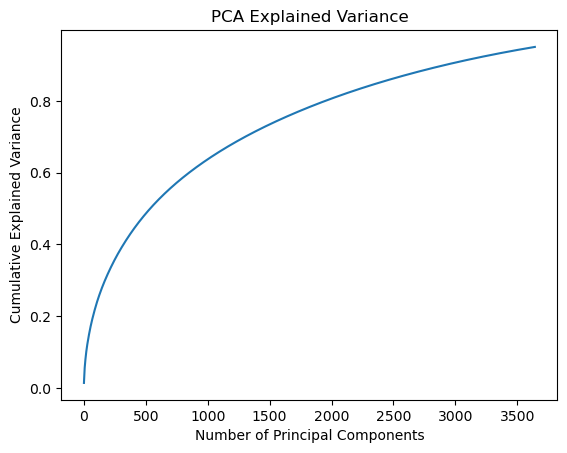

In [27]:
# Plot cumulative explained variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


## 3. Model Selection & Training

#### 3.1 Import Libraries for Model Training

In [30]:
# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB


In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (19826, 3643)
Testing set shape: (4957, 3643)


#### 3.2 Train Logistic Regression

In [33]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### 3.3 Train Support Vector Machine (SVM)

In [35]:
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)


SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

#### 3.4 Train Random Forest Classifier

In [37]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

### 3.5 Train Gradient Boosting Classifier

In [39]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

#### 3.6 Train Naïve Bayes Classifier

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
# X_tfidf is introduced because it does not accept negative values from the PCA output

MultinomialNB()

## 4. Hyperparameter Tuning

In [43]:
# Hyperparameter tuning and cross-validation
from sklearn.model_selection import GridSearchCV


#### 4.1 Hyperparameter Tuning – Logistic Regression

In [45]:
# Define hyperparameter grid for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base model
log_reg = LogisticRegression(max_iter=2000)

# Hyperparameter grid
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

# Grid search
log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

# Fit
log_reg_grid.fit(X_train, y_train)

# Results
print("Best Logistic Regression Parameters:", log_reg_grid.best_params_)
print("Best Score:", log_reg_grid.best_score_)



Best Logistic Regression Parameters: {'C': 10, 'penalty': 'l2'}
Best Score: 0.8819796350450462


#### 4.2 Hyperparameter Tuning – Support Vector Machine (SVM)

In [47]:
# Define hyperparameter grid for SVM
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:", svm_grid.best_params_)


Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}


#### 4.3 Hyperparameter Tuning – Random Forest

In [49]:
# Define hyperparameter grid for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)


Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


#### 4.4 Hyperparameter Tuning – Gradient Boosting

In [51]:
# Define hyperparameter grid for Gradient Boosting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)


Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


#### 4.5 Hyperparameter Tuning – Naïve Bayes

In [53]:
# Define hyperparameter grid for Naïve Bayes
nb_params = {
    'alpha': [0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)

print("Best Naïve Bayes Parameters:", nb_grid.best_params_)


Best Naïve Bayes Parameters: {'alpha': 0.1}


#### 4.6 Store Best Models for Evaluation

In [55]:
# Extract best estimators
best_models = {
    "Logistic Regression": log_reg_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Naïve Bayes": nb_grid.best_estimator_
}

print("Best models selected for evaluation.")


Best models selected for evaluation.


## 5 Model Evaluation & Comparative Analysis

In [57]:
# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    classification_report
)
def evaluate_model(model, X_test, y_test):
    """
    Evaluates a classification model using multiple performance metrics.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_proba, multi_class='ovr'),
        "Log Loss": log_loss(y_test, y_proba),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }


#### 5.1 Evaluate All Tuned Models

In [59]:
evaluation_results = {}

for model_name, model in best_models.items():
    evaluation_results[model_name] = evaluate_model(model, X_test, y_test)

print("Model evaluation completed.")


Model evaluation completed.


#### 5.2 Display Quantitative Results for Each Model

In [61]:
for model_name, results in evaluation_results.items():
    print(f"\nEvaluation Results for {model_name}")
    print("-" * 45)
    print(f"Accuracy   : {results['Accuracy']:.4f}")
    print(f"Precision  : {results['Precision']:.4f}")
    print(f"Recall     : {results['Recall']:.4f}")
    print(f"F1-Score   : {results['F1-Score']:.4f}")
    print(f"ROC-AUC    : {results['ROC-AUC']:.4f}")
    print(f"Log Loss   : {results['Log Loss']:.4f}")



Evaluation Results for Logistic Regression
---------------------------------------------
Accuracy   : 0.8927
Precision  : 0.8815
Recall     : 0.8927
F1-Score   : 0.8851
ROC-AUC    : 0.9106
Log Loss   : 0.3164

Evaluation Results for SVM
---------------------------------------------
Accuracy   : 0.8886
Precision  : 0.8927
Recall     : 0.8886
F1-Score   : 0.8891
ROC-AUC    : 0.9278
Log Loss   : 0.2817

Evaluation Results for Random Forest
---------------------------------------------
Accuracy   : 0.8987
Precision  : 0.8942
Recall     : 0.8987
F1-Score   : 0.8947
ROC-AUC    : 0.9259
Log Loss   : 0.3243

Evaluation Results for Gradient Boosting
---------------------------------------------
Accuracy   : 0.8886
Precision  : 0.8749
Recall     : 0.8886
F1-Score   : 0.8778
ROC-AUC    : 0.9182
Log Loss   : 0.3027

Evaluation Results for Naïve Bayes
---------------------------------------------
Accuracy   : 0.8626
Precision  : 0.8447
Recall     : 0.8626
F1-Score   : 0.8401
ROC-AUC    : 0.8965
Lo

#### 5.3 Classification Reports (Class-Level Analysis)

In [63]:
for model_name, model in best_models.items():
    print(f"\nClassification Report – {model_name}")
    print(classification_report(y_test, model.predict(X_test)))



Classification Report – Logistic Regression
              precision    recall  f1-score   support

           0       0.48      0.27      0.35       286
           1       0.92      0.95      0.94      3838
           2       0.84      0.83      0.84       833

    accuracy                           0.89      4957
   macro avg       0.75      0.68      0.71      4957
weighted avg       0.88      0.89      0.89      4957


Classification Report – SVM
              precision    recall  f1-score   support

           0       0.44      0.41      0.43       286
           1       0.95      0.91      0.93      3838
           2       0.78      0.94      0.85       833

    accuracy                           0.89      4957
   macro avg       0.72      0.76      0.74      4957
weighted avg       0.89      0.89      0.89      4957


Classification Report – Random Forest
              precision    recall  f1-score   support

           0       0.49      0.33      0.40       286
           1    

#### 5.4 Confusion Matrix Analysis

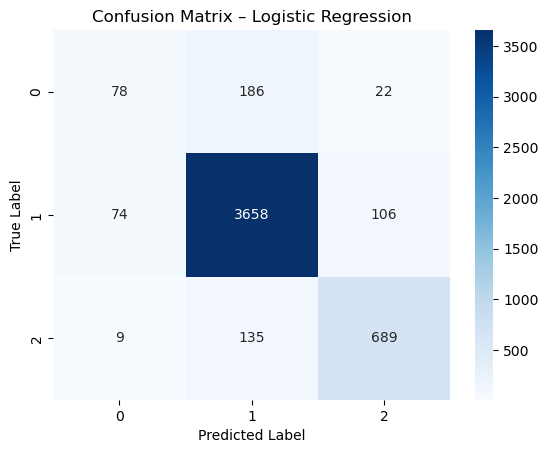

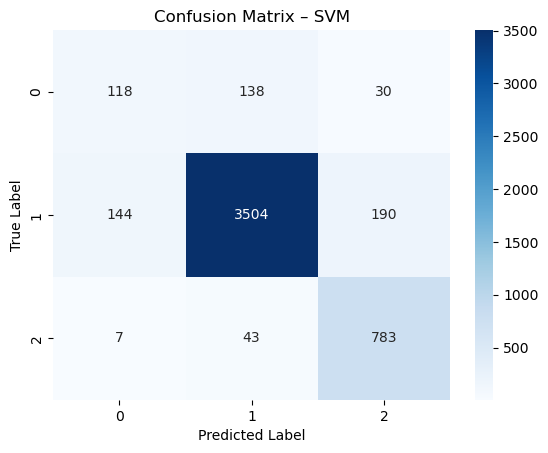

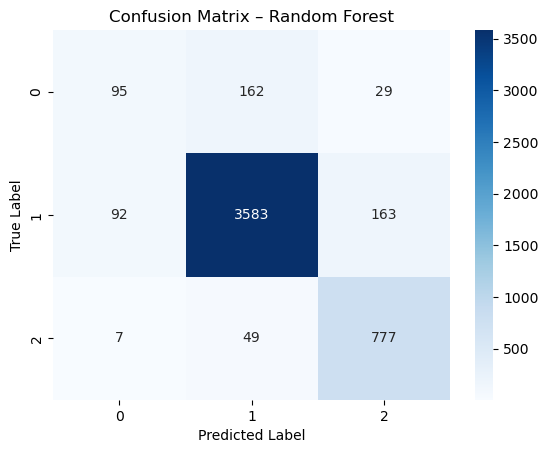

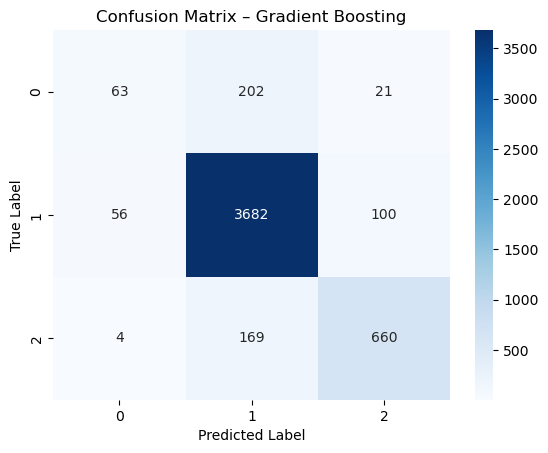

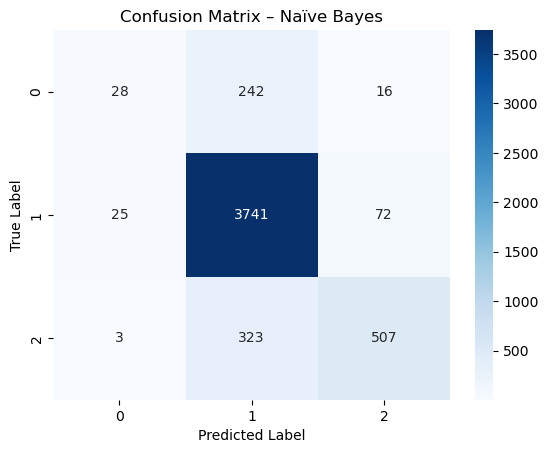

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, results in evaluation_results.items():
    plt.figure()
    sns.heatmap(
        results["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


#### 5.5 Comparative Performance Table

In [67]:
comparison_df = pd.DataFrame.from_dict(
    {
        model: {
            "Accuracy": results["Accuracy"],
            "Precision": results["Precision"],
            "Recall": results["Recall"],
            "F1-Score": results["F1-Score"],
            "ROC-AUC": results["ROC-AUC"],
            "Log Loss": results["Log Loss"]
        }
        for model, results in evaluation_results.items()
    },
    orient="index"
)

comparison_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log Loss
Logistic Regression,0.892677,0.881466,0.892677,0.885114,0.910596,0.316352
SVM,0.888642,0.892723,0.888642,0.889122,0.927751,0.281694
Random Forest,0.898729,0.894201,0.898729,0.894739,0.925949,0.324288
Gradient Boosting,0.888642,0.874947,0.888642,0.877759,0.918154,0.302731
Naïve Bayes,0.862619,0.844706,0.862619,0.840095,0.896545,0.356571


#### 5.6 Best Model Selection

In [69]:
best_model_name = comparison_df["F1-Score"].idxmax()
best_model = best_models[best_model_name]

print("Best Performing Model:", best_model_name)


Best Performing Model: Random Forest


## 6 Model Deployment

#### 6.1 Create a Prediction Function

In [72]:
def predict_hate_speech(text, model, tfidf_vectorizer, pca_model):
    """
    Predicts the class of a given tweet using the deployed model.
    """
    # Clean input text
    text = clean_text(text)
    
    # Transform text using TF-IDF
    text_tfidf = tfidf_vectorizer.transform([text])
    
    # Apply PCA transformation
    text_pca = pca_model.transform(text_tfidf.toarray())
    
    # Generate prediction
    prediction = model.predict(text_pca)
    
    return prediction[0]


#### 6.2 Deploy the Best Model and Test Model on Unseen Data (Realistic Simulation)

In [74]:
def predict_hate_speech(text, model, tfidf_vectorizer):
    text = clean_text(text)
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = model.predict(text_tfidf)
    return prediction[0]

deployed_model = best_model

test_tweets = [
    "I hate these people, they should not exist",
    "What a beautiful day, feeling happy and blessed",
    "You are so stupid and worthless"
]

for tweet in test_tweets:
    result = predict_hate_speech(tweet, deployed_model, tfidf)
    print(f"Tweet: {tweet}")
    print(f"Predicted Class: {result}\n")

Tweet: I hate these people, they should not exist
Predicted Class: 1

Tweet: What a beautiful day, feeling happy and blessed
Predicted Class: 2

Tweet: You are so stupid and worthless
Predicted Class: 2

